## Image processing - food classifier

### Part I - Baseline Evaluation

Using our own collected data as the input to the classification model. Compare the results versus the results from the Food-101 dataset

First test the model is loaded

c:\anaconda250618\envs\ece253_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model initialized, using device: cuda


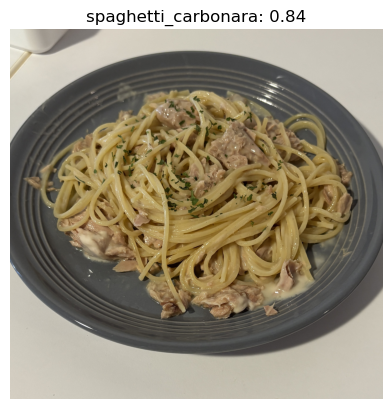

In [1]:
import shutil
import sys
sys.path.insert(0, './src')
from models.classifier import FoodClassifier
from utils import calculate_metrics
import plot

# Initialize the classification model
model = FoodClassifier()

# Model testing, predict a single image
example_image = './data/example.JPG'
results = model.predict_single(example_image)
plot.single_image(example_image, title=f"{results['label']}: {results['confidence']:.2f}")

Run prediction directly on our collected dataset as the baseline

Loaded 44 images from ./data/raw
Predicted 44 images in 5.41s


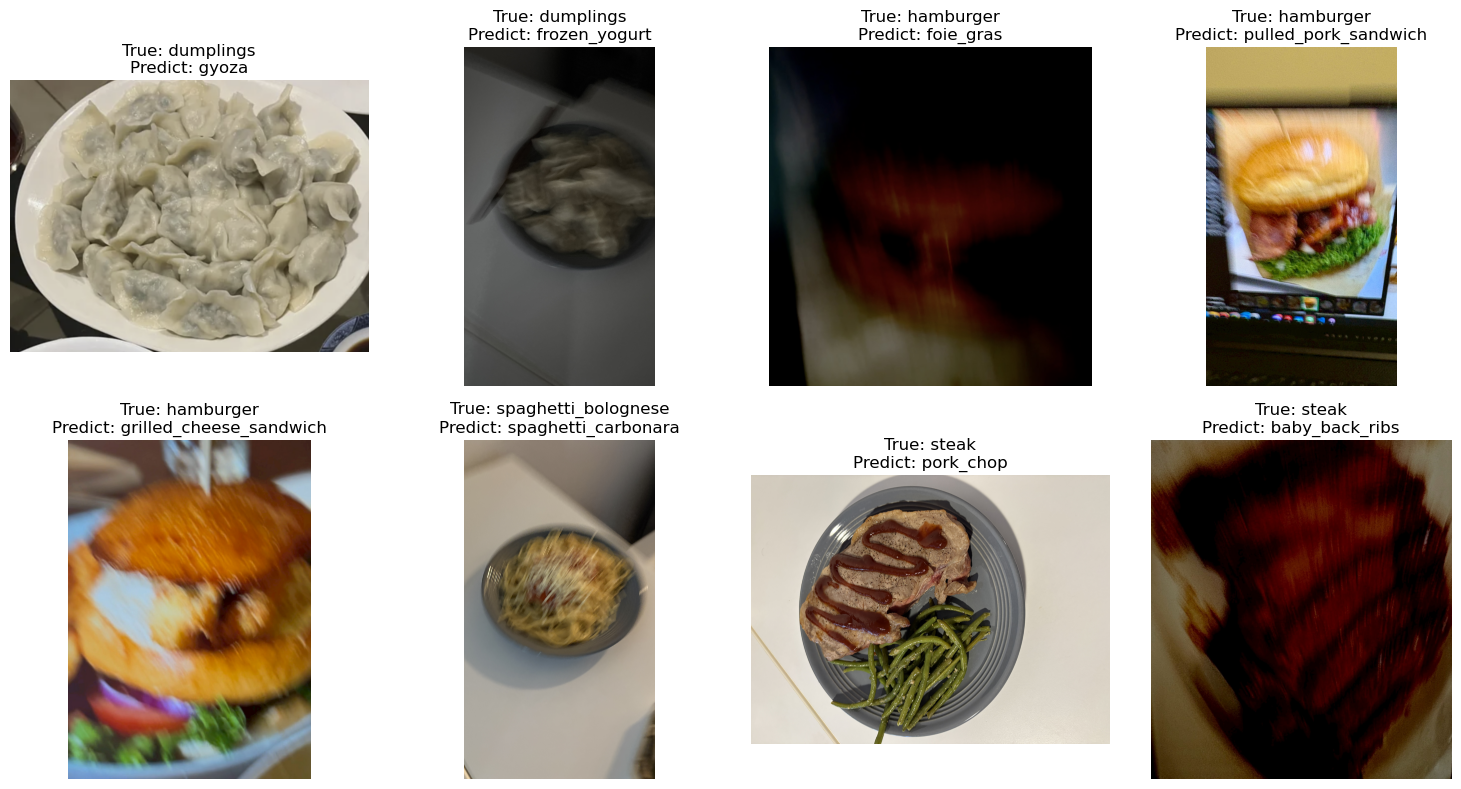

{'accuracy': 0.7954545454545454, 'f1_score': 0.8537878787878789}


In [2]:
dataset_path = './data/raw'
results = model.predict_folder(dataset_path)
plot.wrong_predictions(results, folder = dataset_path)
metrics = calculate_metrics(**results)
print(metrics)

### Part II - Individual Algorithm Evaluation

Process our collected data with the image processing algorithms. Use them as the input to the model

In [3]:
import shutil
from preprocessing.downscaling import downscale_lanczos_224, get_l0_downscaler_224, MatlabEngineManager
from utils import preprocess_folder
import os

output_path = './data/preprocessed'

# 定義下採樣函數列表
downscaling_functions = {
    "Lanczos": downscale_lanczos_224,
}

# 使用 MatlabEngineManager 管理 MATLAB 引擎的生命週期
with MatlabEngineManager():
    # 獲取 L0 下採樣函數
    l0_downscaler_pipeline = get_l0_downscaler_224(lambda_val=2e-4, kappa_val=2)
    downscaling_functions["L0_Downscaling"] = l0_downscaler_pipeline

    for name, func in downscaling_functions.items():
        # 確保每次循環開始時 output_path 都是空的
        if os.path.exists(output_path):
            shutil.rmtree(output_path)
        os.makedirs(output_path)
        
        print(f"Processing with {name}...")
        preprocess_folder(func, input_dir=dataset_path, output_dir=output_path)
        results = model.predict_folder(output_path)
        metrics = calculate_metrics(**results)
        print(f"Metrics for {name}: {metrics}")
        plot.wrong_predictions(results, folder = output_path)

# 清理最終的輸出目錄
if os.path.exists(output_path):
    shutil.rmtree(output_path)



NameError: name 'Image' is not defined

### Part III - Combination Search

### Part IV - Model Fine-Tuning